# Import Libraries

In [54]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import convolve, gaussian_filter, median_filter, prewitt, sobel, uniform_filter
from scipy.signal import wiener
from skimage.metrics import peak_signal_noise_ratio
from skimage.restoration import denoise_bilateral, denoise_nl_means

# Load Sample

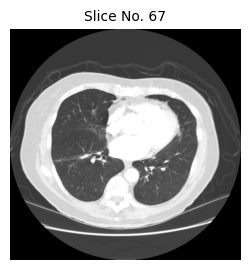

Image Shape: (133, 512, 512)
Pixel Value Type: float32
Min Pixel Value: 0.0
Max Pixel Value: 1.0


In [55]:
IMAGE_PATH = "../000_dataset/_lidc/002_windowed_npy/LIDC-IDRI-0001_30178_03192.npy"

img = np.load(IMAGE_PATH)
mid_slice_idx = math.ceil(img.shape[0] / 2)
img_mid = img[mid_slice_idx]

fig, ax = plt.subplots(figsize=(3, 3))

ax.imshow(img_mid, cmap="gray")
ax.set_title(f"Slice No. {mid_slice_idx}", fontsize=10)
ax.grid(False)
ax.axis("off")

plt.show()

print(f"Image Shape: {img.shape}")
print(f"Pixel Value Type: {img.dtype}")
print(f"Min Pixel Value: {img.min()}")
print(f"Max Pixel Value: {img.max()}")

# Smoothing/Noise Reduction

## Mean Filter

A mean filter smooths an image by convolving it with a normalized kernel whose elements have equal weights. Each output pixel is therefore the average of the pixels covered by the kernel. This reduces noise and local intensity variations, but may blur edges and fine details. 

It is suitable for images with mild random intensity fluctuations and relatively homogeneous regions when preserving fine edges is not the main priority.

$$
g(x,y) = (f * h)(x,y) = \sum_{i=-a}^{a} \sum_{j=-b}^{b} h(i,j)f(x-i,y-j)
$$

where $f$ is the input image, $h$ is the mean-filter kernel, $*$ denotes convolution, and $g$ is the filtered image. For a $3 \times 3$ mean filter, the kernel is:

$$
h = \frac{1}{9}\begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}
$$

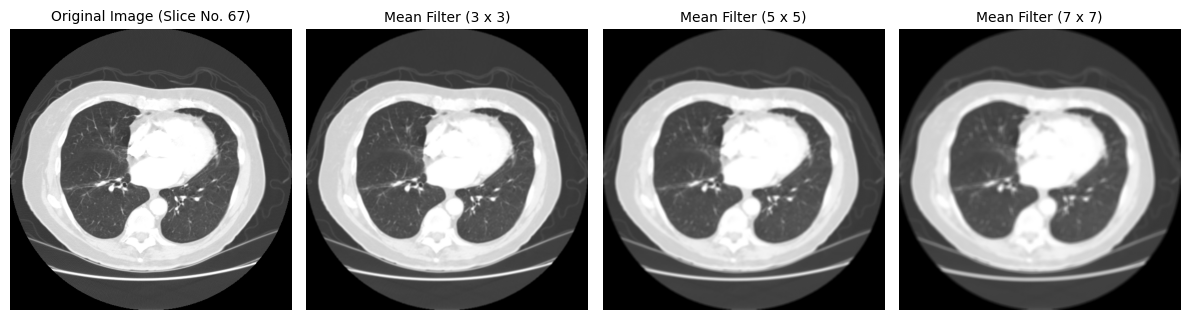

In [56]:
# Implement mean filter.
kernel_sizes = [3, 5, 7]

mean_filtered_images = [
    uniform_filter(img_mid, size=(kernel_size, kernel_size), mode="reflect")
    for kernel_size in kernel_sizes
]

images = [img_mid, *mean_filtered_images]
titles = [
    f"Original Image (Slice No. {mid_slice_idx})",
    *[f"Mean Filter ({kernel_size} x {kernel_size})" for kernel_size in kernel_sizes],
]

fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(12, 4))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(
        image,
        cmap="gray",
        vmin=img_mid.min(),
        vmax=img_mid.max(),
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

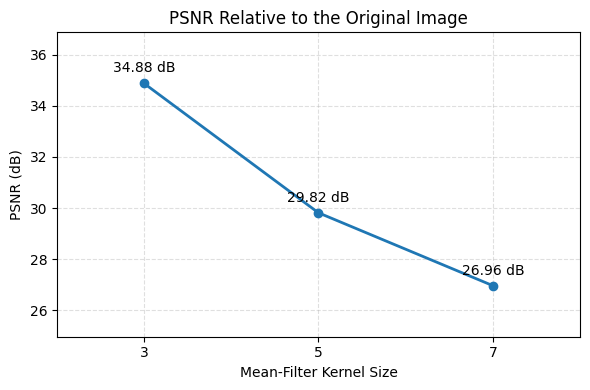

In [57]:
# PSNR quantifies the change relative to the original image.
data_range = img_mid.max() - img_mid.min()

psnr_values = [
    peak_signal_noise_ratio(img_mid, image, data_range=data_range)
    for image in mean_filtered_images
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kernel_sizes, psnr_values, marker="o", linewidth=2)

psnr_span = max(psnr_values) - min(psnr_values)
kernel_span = max(kernel_sizes) - min(kernel_sizes)
vertical_padding = max(0.25 * psnr_span, 2.0)
horizontal_padding = max(0.25 * kernel_span, 1)
ax.set_ylim(
    min(psnr_values) - vertical_padding,
    max(psnr_values) + vertical_padding,
)
ax.set_xlim(
    min(kernel_sizes) - horizontal_padding,
    max(kernel_sizes) + horizontal_padding,
)

for kernel_size, psnr in zip(kernel_sizes, psnr_values):
    ax.annotate(
        f"{psnr:.2f} dB",
        (kernel_size, psnr),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("PSNR Relative to the Original Image")
ax.set_xlabel("Mean-Filter Kernel Size")
ax.set_ylabel("PSNR (dB)")
ax.set_xticks(kernel_sizes)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Gaussian Filter

A Gaussian filter smooths an image by convolving it with a Gaussian-weighted kernel. Pixels near the kernel center receive higher weights than pixels farther away, resulting in smoother and more natural noise reduction than a mean filter. The standard deviation $\sigma$ controls the smoothing strength. 

It is suitable for images affected by Gaussian or sensor noise and is commonly used before edge detection, segmentation, or feature extraction when gradual smoothing is desired.

$$
G(x,y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
$$

The filtered image is obtained through convolution: $g(x,y) = (f * G)(x,y)$.

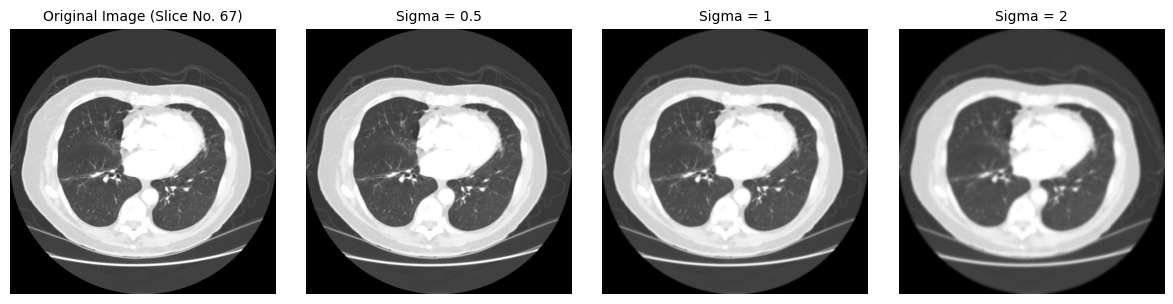

In [58]:
sigma_value = [0.5, 1, 2]

gaussian_filtered_images = [
    gaussian_filter(img_mid, sigma=sigma, mode="reflect")
    for sigma in sigma_value
]

images = [img_mid, *gaussian_filtered_images]
titles = [
    f"Original Image (Slice No. {mid_slice_idx})",
    *[f"Sigma = {sigma}"for sigma in sigma_value],
]

fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(12, 3))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(
        image,
        cmap="gray",
        vmin=img_mid.min(),
        vmax=img_mid.max(),
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

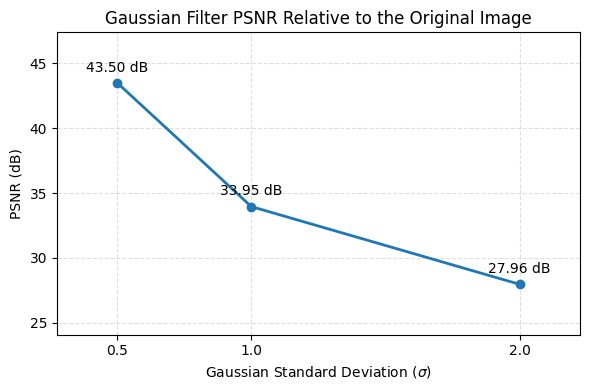

In [59]:
# PSNR quantifies the change relative to the original image.
data_range = img_mid.max() - img_mid.min()
gaussian_psnr_values = [
    peak_signal_noise_ratio(img_mid, image, data_range=data_range)
    for image in gaussian_filtered_images
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sigma_value, gaussian_psnr_values, marker="o", linewidth=2)

# Add padding
sigma_span = max(sigma_value) - min(sigma_value)
horizontal_padding = max(0.15 * sigma_span, 0.1)
ax.set_xlim(
    min(sigma_value) - horizontal_padding,
    max(sigma_value) + horizontal_padding,
)

psnr_span = max(gaussian_psnr_values) - min(gaussian_psnr_values)
vertical_padding = max(0.25 * psnr_span, 2.0)
ax.set_ylim(
    min(gaussian_psnr_values) - vertical_padding,
    max(gaussian_psnr_values) + vertical_padding,
)

for sigma, psnr in zip(sigma_value, gaussian_psnr_values):
    ax.annotate(
        f"{psnr:.2f} dB",
        (sigma, psnr),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Gaussian Filter PSNR Relative to the Original Image")
ax.set_xlabel(r"Gaussian Standard Deviation ($\sigma$)")
ax.set_ylabel("PSNR (dB)")
ax.set_xticks(sigma_value)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Median Filter

A median filter is a nonlinear smoothing technique that replaces each pixel with the median intensity of its neighborhood. It effectively removes isolated extreme values while preserving edges better than averaging-based filters. 

It is particularly suitable for images affected by salt-and-pepper or impulse noise.

$$
g(x,y) = \operatorname{median}\left\{f(x+i,y+j) \mid (i,j) \in \mathcal{W}\right\}
$$

where $f$ is the input image, $\mathcal{W}$ is the local neighborhood, and $g$ is the filtered image.

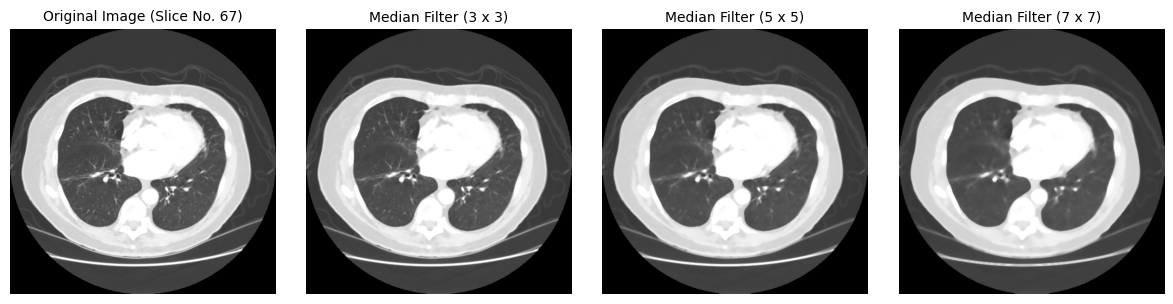

In [60]:
# Implement median filter.
median_kernel_sizes = [3, 5, 7]

median_filtered_images = [
    median_filter(img_mid, size=(kernel_size, kernel_size), mode="reflect")
    for kernel_size in median_kernel_sizes
]

images = [img_mid, *median_filtered_images]
titles = [
    f"Original Image (Slice No. {mid_slice_idx})",
    *[
        f"Median Filter ({kernel_size} x {kernel_size})"
        for kernel_size in median_kernel_sizes
    ],
]

fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(12, 3))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(
        image,
        cmap="gray",
        vmin=img_mid.min(),
        vmax=img_mid.max(),
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

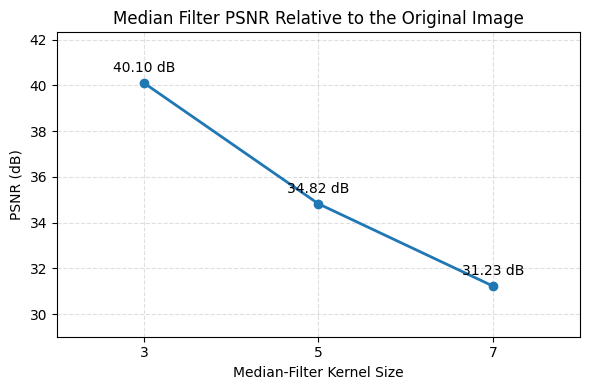

In [61]:
# PSNR quantifies the change relative to the original image.
data_range = img_mid.max() - img_mid.min()
median_psnr_values = [
    peak_signal_noise_ratio(img_mid, image, data_range=data_range)
    for image in median_filtered_images
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(median_kernel_sizes, median_psnr_values, marker="o", linewidth=2)

kernel_span = max(median_kernel_sizes) - min(median_kernel_sizes)
horizontal_padding = max(0.25 * kernel_span, 1.0)
ax.set_xlim(
    min(median_kernel_sizes) - horizontal_padding,
    max(median_kernel_sizes) + horizontal_padding,
)

psnr_span = max(median_psnr_values) - min(median_psnr_values)
vertical_padding = max(0.25 * psnr_span, 2.0)
ax.set_ylim(
    min(median_psnr_values) - vertical_padding,
    max(median_psnr_values) + vertical_padding,
)

for kernel_size, psnr in zip(median_kernel_sizes, median_psnr_values):
    ax.annotate(
        f"{psnr:.2f} dB",
        (kernel_size, psnr),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Median Filter PSNR Relative to the Original Image")
ax.set_xlabel("Median-Filter Kernel Size")
ax.set_ylabel("PSNR (dB)")
ax.set_xticks(median_kernel_sizes)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Bilateral Filter

A bilateral filter is a nonlinear, edge-preserving smoothing technique that combines spatial distance and intensity similarity. Nearby pixels with similar intensities receive high weights, while pixels across an edge receive low weights. 

It is suitable when noise reduction is required without strongly blurring anatomical boundaries, edges, or other important structures.

$$
g(p) = \frac{1}{W_p} \sum_{q \in \Omega} \exp\left(-\frac{\lVert p-q \rVert^2}{2\sigma_s^2}\right) \exp\left(-\frac{(f(p)-f(q))^2}{2\sigma_r^2}\right) f(q)
$$

where $\sigma_s$ controls the spatial extent, $\sigma_r$ controls intensity similarity, and $W_p$ normalizes the weights.

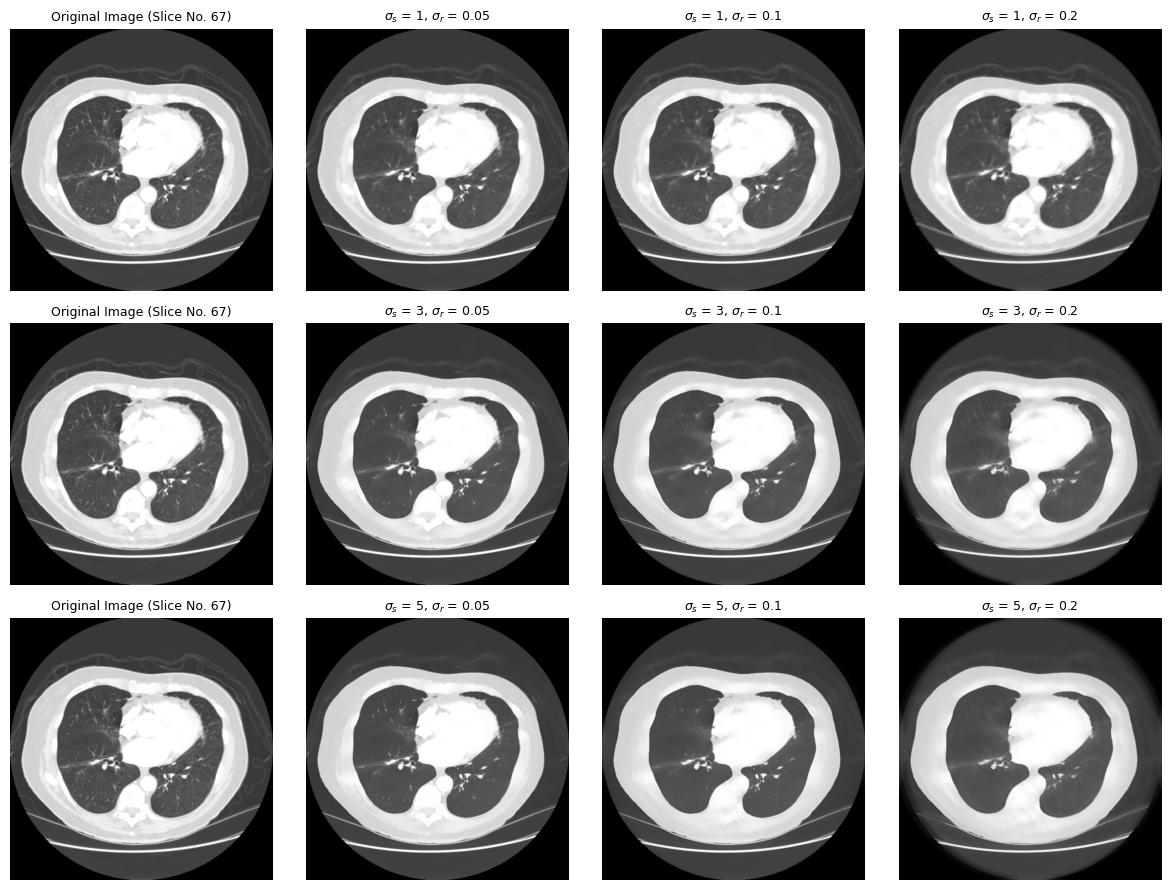

In [62]:
# Implement bilateral filter.
bilateral_sigma_color_values = [0.05, 0.1, 0.2]
bilateral_sigma_spatial_values = [1, 3, 5]

bilateral_filtered_images = {
    (sigma_spatial, sigma_color): denoise_bilateral(
        img_mid,
        sigma_color=sigma_color,
        sigma_spatial=sigma_spatial,
        mode="reflect",
        channel_axis=None,
    )
    for sigma_spatial in bilateral_sigma_spatial_values
    for sigma_color in bilateral_sigma_color_values
}

fig, axes = plt.subplots(
    nrows=len(bilateral_sigma_spatial_values),
    ncols=len(bilateral_sigma_color_values) + 1,
    figsize=(12, 9),
)

for row, sigma_spatial in enumerate(bilateral_sigma_spatial_values):
    axes[row, 0].imshow(
        img_mid,
        cmap="gray",
        vmin=img_mid.min(),
        vmax=img_mid.max(),
    )
    axes[row, 0].set_title(
        f"Original Image (Slice No. {mid_slice_idx})", fontsize=9
    )
    axes[row, 0].axis("off")

    for col, sigma_color in enumerate(bilateral_sigma_color_values, start=1):
        image = bilateral_filtered_images[(sigma_spatial, sigma_color)]
        axes[row, col].imshow(
            image,
            cmap="gray",
            vmin=img_mid.min(),
            vmax=img_mid.max(),
        )
        axes[row, col].set_title(
            rf"$\sigma_s$ = {sigma_spatial}, $\sigma_r$ = {sigma_color}",
            fontsize=9,
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

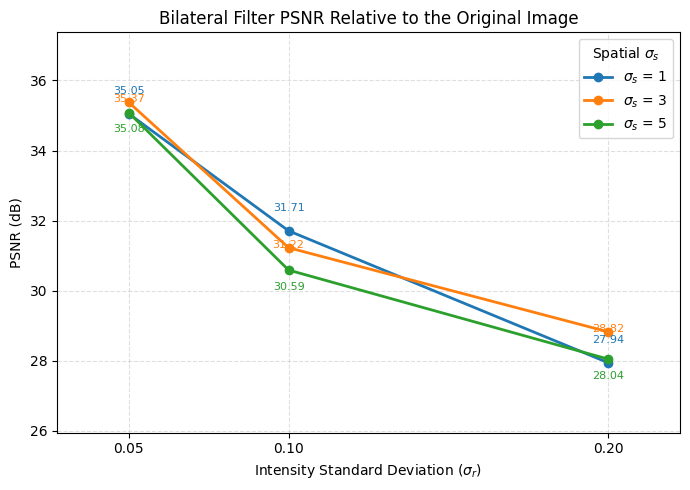

In [63]:
# PSNR quantifies the change relative to the original image.
data_range = img_mid.max() - img_mid.min()
bilateral_psnr_values = {
    sigma_spatial: [
        peak_signal_noise_ratio(
            img_mid,
            bilateral_filtered_images[(sigma_spatial, sigma_color)],
            data_range=data_range,
        )
        for sigma_color in bilateral_sigma_color_values
    ]
    for sigma_spatial in bilateral_sigma_spatial_values
}

fig, ax = plt.subplots(figsize=(7, 5))
annotation_offsets = [14, 0, -14]

for series_index, sigma_spatial in enumerate(bilateral_sigma_spatial_values):
    psnr_values = bilateral_psnr_values[sigma_spatial]
    (line,) = ax.plot(
        bilateral_sigma_color_values,
        psnr_values,
        marker="o",
        linewidth=2,
        label=rf"$\sigma_s$ = {sigma_spatial}",
    )

    for sigma_color, psnr in zip(bilateral_sigma_color_values, psnr_values):
        ax.annotate(
            f"{psnr:.2f}",
            (sigma_color, psnr),
            xytext=(0, annotation_offsets[series_index]),
            textcoords="offset points",
            ha="center",
            color=line.get_color(),
            fontsize=8,
        )

sigma_span = max(bilateral_sigma_color_values) - min(bilateral_sigma_color_values)
horizontal_padding = max(0.15 * sigma_span, 0.01)
ax.set_xlim(
    min(bilateral_sigma_color_values) - horizontal_padding,
    max(bilateral_sigma_color_values) + horizontal_padding,
)

all_bilateral_psnr_values = [
    psnr
    for psnr_values in bilateral_psnr_values.values()
    for psnr in psnr_values
]
psnr_span = max(all_bilateral_psnr_values) - min(all_bilateral_psnr_values)
vertical_padding = max(0.25 * psnr_span, 2.0)
ax.set_ylim(
    min(all_bilateral_psnr_values) - vertical_padding,
    max(all_bilateral_psnr_values) + vertical_padding,
)

ax.set_title("Bilateral Filter PSNR Relative to the Original Image")
ax.set_xlabel(r"Intensity Standard Deviation ($\sigma_r$)")
ax.set_ylabel("PSNR (dB)")
ax.set_xticks(bilateral_sigma_color_values)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title=r"Spatial $\sigma_s$")

plt.tight_layout()
plt.show()

## Non-Local Means Filter

A Non-Local Means (NLM) filter denoises an image by averaging pixels with similar surrounding patches, even when they are spatially far apart. Similar patches receive higher weights, allowing noise reduction while retaining repeated textures and fine structures. 

It is suitable for noisy medical or natural images that contain recurring patterns and when detail preservation is important, although it is more computationally expensive than local filters.

$$
\hat{f}(p) = \frac{1}{C(p)} \sum_{q \in \Omega} \exp\left(-\frac{\lVert P_p-P_q \rVert_2^2}{h^2}\right) f(q)
$$

where $P_p$ and $P_q$ are patches centered at pixels $p$ and $q$, $h$ controls the filtering strength, and $C(p)$ normalizes the weights.

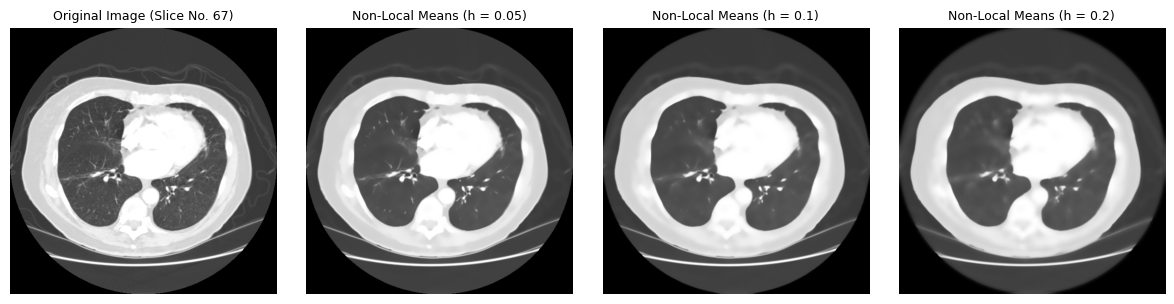

In [64]:
# Implement Non-Local Means filter.
nlm_h_values = [0.05, 0.1, 0.2]
nlm_patch_size = 5
nlm_patch_distance = 6

nlm_filtered_images = [
    denoise_nl_means(
        img_mid,
        h=h_value,
        patch_size=nlm_patch_size,
        patch_distance=nlm_patch_distance,
        fast_mode=True,
        preserve_range=True,
        channel_axis=None,
    )
    for h_value in nlm_h_values
]

images = [img_mid, *nlm_filtered_images]
titles = [
    f"Original Image (Slice No. {mid_slice_idx})",
    *[f"Non-Local Means (h = {h_value})" for h_value in nlm_h_values],
]

fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(12, 3))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(
        image,
        cmap="gray",
        vmin=img_mid.min(),
        vmax=img_mid.max(),
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

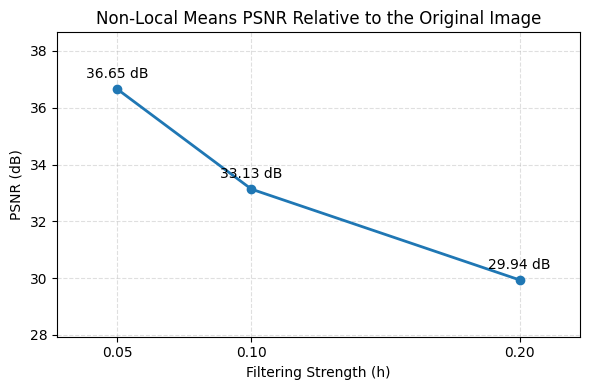

In [65]:
# PSNR quantifies the change relative to the original image.
data_range = img_mid.max() - img_mid.min()
nlm_psnr_values = [
    peak_signal_noise_ratio(img_mid, image, data_range=data_range)
    for image in nlm_filtered_images
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(nlm_h_values, nlm_psnr_values, marker="o", linewidth=2)

h_span = max(nlm_h_values) - min(nlm_h_values)
horizontal_padding = max(0.15 * h_span, 0.01)
ax.set_xlim(
    min(nlm_h_values) - horizontal_padding,
    max(nlm_h_values) + horizontal_padding,
)

psnr_span = max(nlm_psnr_values) - min(nlm_psnr_values)
vertical_padding = max(0.25 * psnr_span, 2.0)
ax.set_ylim(
    min(nlm_psnr_values) - vertical_padding,
    max(nlm_psnr_values) + vertical_padding,
)

for h_value, psnr in zip(nlm_h_values, nlm_psnr_values):
    ax.annotate(
        f"{psnr:.2f} dB",
        (h_value, psnr),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Non-Local Means PSNR Relative to the Original Image")
ax.set_xlabel("Filtering Strength (h)")
ax.set_ylabel("PSNR (dB)")
ax.set_xticks(nlm_h_values)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Wiener Filter

A Wiener filter is an adaptive smoothing technique that estimates each output pixel from the local mean and variance while accounting for the noise variance. It applies stronger smoothing in homogeneous regions and preserves more detail in high-variance regions. It is suitable for images affected by additive Gaussian noise when local image statistics can be estimated reliably.

$$
g(x,y) = \mu_L + \max\left(0, \frac{\sigma_L^2-\sigma_n^2}{\sigma_L^2}\right)\left[f(x,y)-\mu_L\right]
$$

where $\mu_L$ and $\sigma_L^2$ are the local mean and variance, and $\sigma_n^2$ is the estimated noise variance.

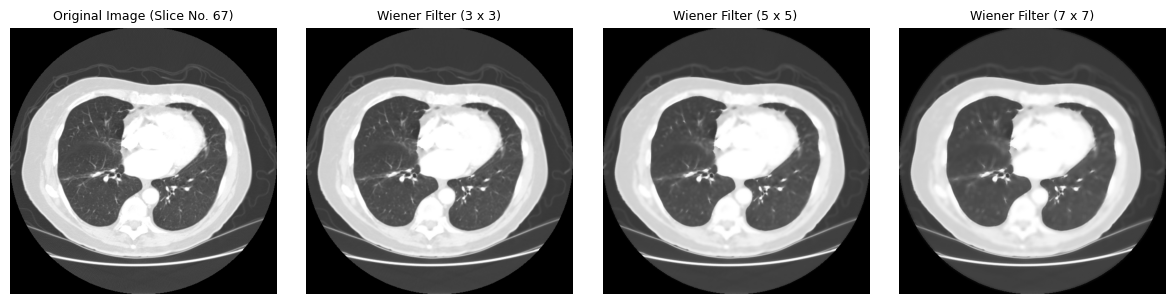

In [66]:
# Implement Wiener filter.
wiener_kernel_sizes = [3, 5, 7]

wiener_filtered_images = [
    np.clip(
        wiener(img_mid, mysize=(kernel_size, kernel_size)),
        img_mid.min(),
        img_mid.max(),
    )
    for kernel_size in wiener_kernel_sizes
]

images = [img_mid, *wiener_filtered_images]
titles = [
    f"Original Image (Slice No. {mid_slice_idx})",
    *[
        f"Wiener Filter ({kernel_size} x {kernel_size})"
        for kernel_size in wiener_kernel_sizes
    ],
]

fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(12, 3))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(
        image,
        cmap="gray",
        vmin=img_mid.min(),
        vmax=img_mid.max(),
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

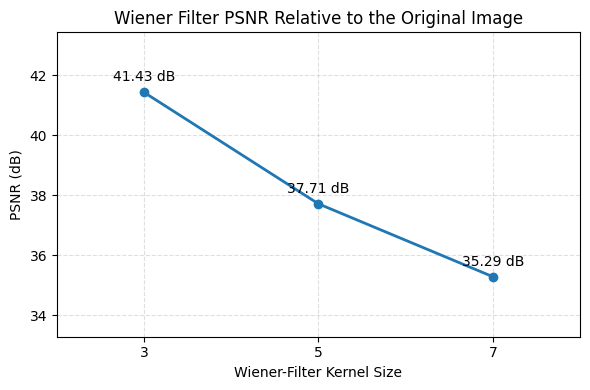

In [67]:
# PSNR quantifies the change relative to the original image.
data_range = img_mid.max() - img_mid.min()
wiener_psnr_values = [
    peak_signal_noise_ratio(img_mid, image, data_range=data_range)
    for image in wiener_filtered_images
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(wiener_kernel_sizes, wiener_psnr_values, marker="o", linewidth=2)

kernel_span = max(wiener_kernel_sizes) - min(wiener_kernel_sizes)
horizontal_padding = max(0.25 * kernel_span, 1.0)
ax.set_xlim(
    min(wiener_kernel_sizes) - horizontal_padding,
    max(wiener_kernel_sizes) + horizontal_padding,
)

psnr_span = max(wiener_psnr_values) - min(wiener_psnr_values)
vertical_padding = max(0.25 * psnr_span, 2.0)
ax.set_ylim(
    min(wiener_psnr_values) - vertical_padding,
    max(wiener_psnr_values) + vertical_padding,
)

for kernel_size, psnr in zip(wiener_kernel_sizes, wiener_psnr_values):
    ax.annotate(
        f"{psnr:.2f} dB",
        (kernel_size, psnr),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Wiener Filter PSNR Relative to the Original Image")
ax.set_xlabel("Wiener-Filter Kernel Size")
ax.set_ylabel("PSNR (dB)")
ax.set_xticks(wiener_kernel_sizes)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Edge Detection

## Sobel Filter

The Sobel filter detects edges by approximating the horizontal and vertical intensity gradients with two $3 \times 3$ convolution kernels. Large gradient magnitudes indicate rapid intensity changes and therefore potential object boundaries. 

It is suitable for detecting strong, relatively continuous edges when a fast and simple method is required. Because Sobel is sensitive to noise, smoothing is commonly applied before edge detection.

$$
K_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \qquad
K_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}
$$

The horizontal and vertical responses are $G_x=f*K_x$ and $G_y=f*K_y$. The final edge strength is computed as:

$$
G = \sqrt{G_x^2 + G_y^2}
$$

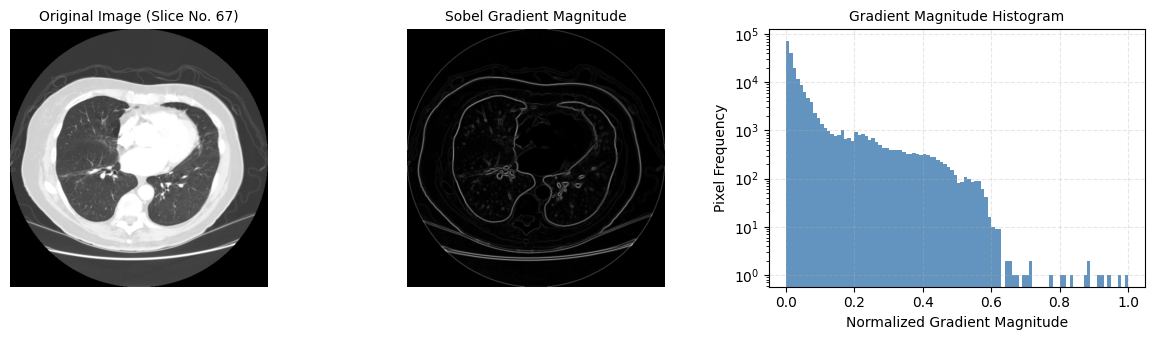

In [68]:
# Compute horizontal and vertical Sobel responses.
sobel_x = sobel(img_mid, axis=1, mode="reflect")
sobel_y = sobel(img_mid, axis=0, mode="reflect")
sobel_gradient = np.hypot(sobel_x, sobel_y)
sobel_gradient_normalized = sobel_gradient / (sobel_gradient.max() + np.finfo(float).eps)

# Exclude exact zeros so the background does not dominate the histogram.
gradient_values = sobel_gradient_normalized[sobel_gradient_normalized > 0]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 3.5),
    gridspec_kw={"width_ratios": [1, 1, 1.15]},
)

axes[0].imshow(img_mid, cmap="gray")
axes[0].set_title(f"Original Image (Slice No. {mid_slice_idx})", fontsize=10)
axes[0].axis("off")

axes[1].imshow(sobel_gradient_normalized, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Sobel Gradient Magnitude", fontsize=10)
axes[1].axis("off")

axes[2].hist(gradient_values, bins=100, color="steelblue", alpha=0.85)
axes[2].set_title("Gradient Magnitude Histogram", fontsize=10)
axes[2].set_xlabel("Normalized Gradient Magnitude")
axes[2].set_ylabel("Pixel Frequency")
axes[2].set_yscale("log")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Prewitt Filter

The Prewitt filter detects edges by estimating horizontal and vertical intensity gradients with two $3 \times 3$ convolution kernels. Unlike Sobel, it uses uniform weights across each kernel direction, making it simpler but slightly more sensitive to noise. It is suitable for detecting strong, clearly defined edges in images with relatively low noise when computational simplicity is preferred.

$$
K_x = \begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix}, \qquad
K_y = \begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ 1 & 1 & 1 \end{bmatrix}
$$

The horizontal and vertical responses are $G_x=f*K_x$ and $G_y=f*K_y$. The final edge strength is:

$$
G = \sqrt{G_x^2 + G_y^2}
$$

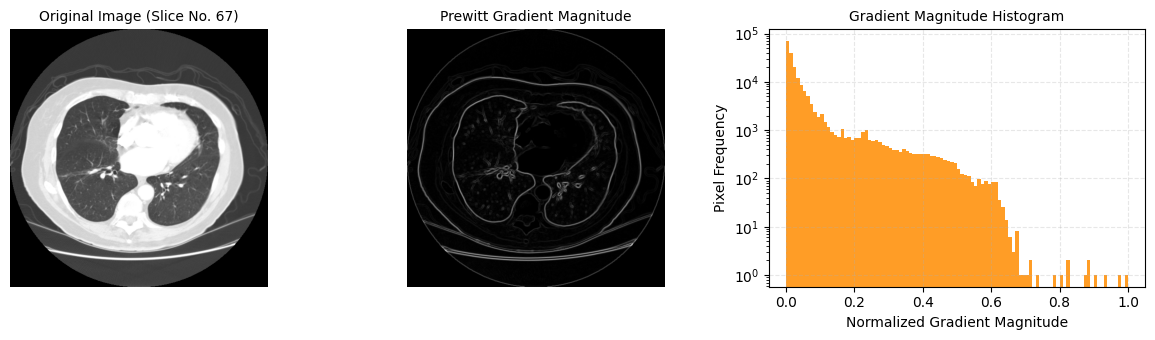

In [69]:
# Compute horizontal and vertical Prewitt responses.
prewitt_x = prewitt(img_mid, axis=1, mode="reflect")
prewitt_y = prewitt(img_mid, axis=0, mode="reflect")
prewitt_gradient = np.hypot(prewitt_x, prewitt_y)
prewitt_gradient_normalized = prewitt_gradient / (
    prewitt_gradient.max() + np.finfo(float).eps
)

# Exclude exact zeros so the background does not dominate the histogram.
prewitt_gradient_values = prewitt_gradient_normalized[
    prewitt_gradient_normalized > 0
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 3.5),
    gridspec_kw={"width_ratios": [1, 1, 1.15]},
)

axes[0].imshow(img_mid, cmap="gray")
axes[0].set_title(f"Original Image (Slice No. {mid_slice_idx})", fontsize=10)
axes[0].axis("off")

axes[1].imshow(prewitt_gradient_normalized, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Prewitt Gradient Magnitude", fontsize=10)
axes[1].axis("off")

axes[2].hist(
    prewitt_gradient_values, bins=100, color="darkorange", alpha=0.85
)
axes[2].set_title("Gradient Magnitude Histogram", fontsize=10)
axes[2].set_xlabel("Normalized Gradient Magnitude")
axes[2].set_ylabel("Pixel Frequency")
axes[2].set_yscale("log")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Scharr Filter

The Scharr filter detects edges by estimating horizontal and vertical intensity gradients with optimized $3 \times 3$ kernels. Its larger central weights provide better rotational symmetry and more accurate gradient responses than Sobel for small kernels. It is suitable when edge strength and orientation must remain consistent across different directions, although smoothing may still be required for noisy images.

$$
K_x = \begin{bmatrix} -3 & 0 & 3 \\ -10 & 0 & 10 \\ -3 & 0 & 3 \end{bmatrix}, \qquad
K_y = \begin{bmatrix} -3 & -10 & -3 \\ 0 & 0 & 0 \\ 3 & 10 & 3 \end{bmatrix}
$$

The final edge strength is computed from the directional responses as $G=\sqrt{G_x^2+G_y^2}$.

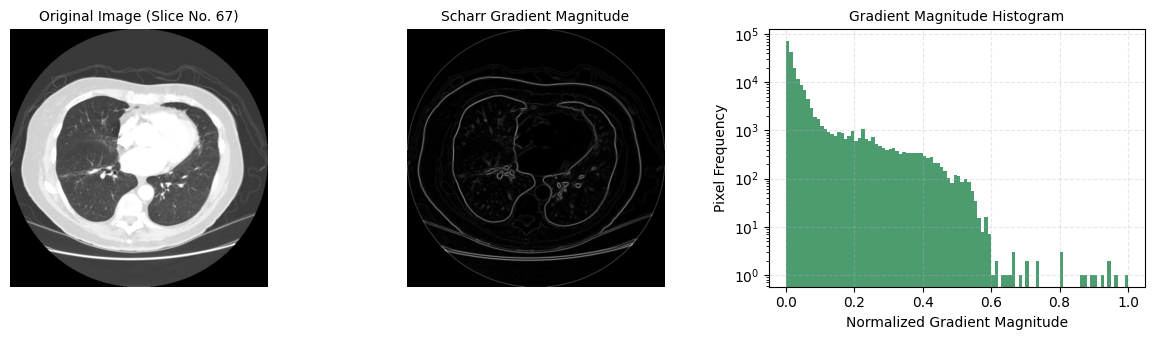

In [70]:
# Define and apply the horizontal and vertical Scharr kernels.
scharr_kernel_x = np.array(
    [[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=np.float32
)
scharr_kernel_y = np.array(
    [[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=np.float32
)
scharr_x = convolve(img_mid, scharr_kernel_x, mode="reflect")
scharr_y = convolve(img_mid, scharr_kernel_y, mode="reflect")
scharr_gradient = np.hypot(scharr_x, scharr_y)
scharr_gradient_normalized = scharr_gradient / (
    scharr_gradient.max() + np.finfo(float).eps
)
scharr_gradient_values = scharr_gradient_normalized[
    scharr_gradient_normalized > 0
]

fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 1, 1.15]}
)
axes[0].imshow(img_mid, cmap="gray")
axes[0].set_title(f"Original Image (Slice No. {mid_slice_idx})", fontsize=10)
axes[0].axis("off")

axes[1].imshow(scharr_gradient_normalized, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Scharr Gradient Magnitude", fontsize=10)
axes[1].axis("off")

axes[2].hist(
    scharr_gradient_values, bins=100, color="seagreen", alpha=0.85
)
axes[2].set_title("Gradient Magnitude Histogram", fontsize=10)
axes[2].set_xlabel("Normalized Gradient Magnitude")
axes[2].set_ylabel("Pixel Frequency")
axes[2].set_yscale("log")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Roberts Filter

The Roberts filter detects edges from diagonal intensity differences using two compact $2 \times 2$ kernels. It is computationally efficient and provides precise localization of sharp edges, but its small kernels make it highly sensitive to noise. It is suitable for high-contrast, low-noise images when fast detection of fine or diagonal edges is required.

$$
K_x = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}, \qquad
K_y = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix}
$$

The final edge strength is computed as $G=\sqrt{G_x^2+G_y^2}$.

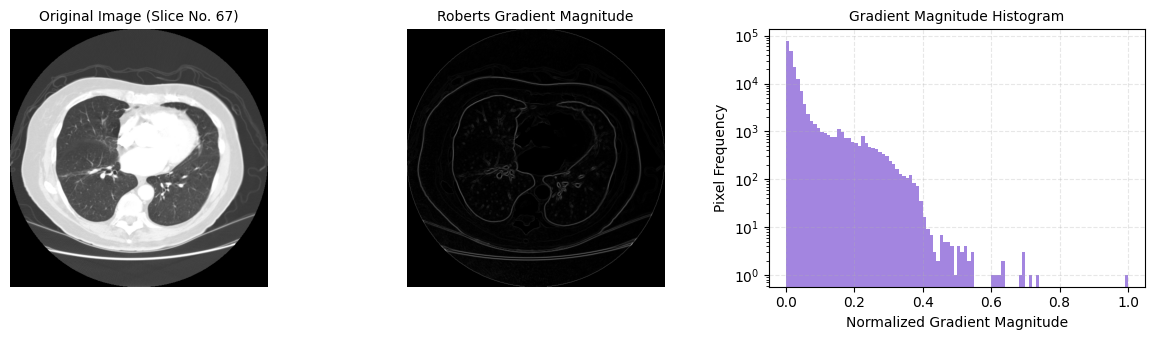

In [71]:
# Define and apply the two diagonal Roberts kernels.
roberts_kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x = convolve(img_mid, roberts_kernel_x, mode="reflect")
roberts_y = convolve(img_mid, roberts_kernel_y, mode="reflect")
roberts_gradient = np.hypot(roberts_x, roberts_y)
roberts_gradient_normalized = roberts_gradient / (
    roberts_gradient.max() + np.finfo(float).eps
)
roberts_gradient_values = roberts_gradient_normalized[
    roberts_gradient_normalized > 0
]

fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 1, 1.15]}
)
axes[0].imshow(img_mid, cmap="gray")
axes[0].set_title(f"Original Image (Slice No. {mid_slice_idx})", fontsize=10)
axes[0].axis("off")

axes[1].imshow(roberts_gradient_normalized, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Roberts Gradient Magnitude", fontsize=10)
axes[1].axis("off")

axes[2].hist(
    roberts_gradient_values, bins=100, color="mediumpurple", alpha=0.85
)
axes[2].set_title("Gradient Magnitude Histogram", fontsize=10)
axes[2].set_xlabel("Normalized Gradient Magnitude")
axes[2].set_ylabel("Pixel Frequency")
axes[2].set_yscale("log")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Laplacian Filter

The Laplacian filter is a second-order derivative operator that detects rapid intensity changes in all directions with a single convolution kernel. It can produce thin edge responses but is highly sensitive to noise and may generate double edges around transitions. It is suitable for highlighting sharp boundaries or fine structures after the image has first been smoothed, commonly with a Gaussian filter.

$$
K_L = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}
$$

The Laplacian response is $L=f*K_L$, and its absolute magnitude $G=|L|$ is displayed as the edge strength.

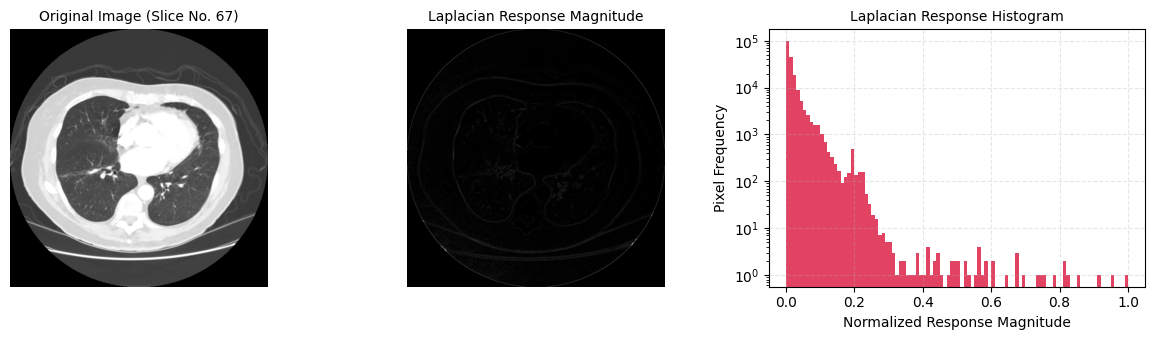

In [72]:
# Define and apply the four-neighbor Laplacian kernel.
laplacian_kernel = np.array(
    [[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32
)
laplacian_response = convolve(img_mid, laplacian_kernel, mode="reflect")
laplacian_magnitude = np.abs(laplacian_response)
laplacian_magnitude_normalized = laplacian_magnitude / (
    laplacian_magnitude.max() + np.finfo(float).eps
)
laplacian_values = laplacian_magnitude_normalized[
    laplacian_magnitude_normalized > 0
]

fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 1, 1.15]}
)
axes[0].imshow(img_mid, cmap="gray")
axes[0].set_title(f"Original Image (Slice No. {mid_slice_idx})", fontsize=10)
axes[0].axis("off")

axes[1].imshow(laplacian_magnitude_normalized, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Laplacian Response Magnitude", fontsize=10)
axes[1].axis("off")

axes[2].hist(laplacian_values, bins=100, color="crimson", alpha=0.80)
axes[2].set_title("Laplacian Response Histogram", fontsize=10)
axes[2].set_xlabel("Normalized Response Magnitude")
axes[2].set_ylabel("Pixel Frequency")
axes[2].set_yscale("log")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()